In [1]:
import math
import warnings

import pandas as pd
import matplotlib.pyplot as plt

## Dataverwerking

In [2]:
# Keys to avoid typos
CATEGORY = 'category'
COUNTRY = 'country'
YEAR = 'year'
PERCENTAGE = 'percentage'

In [3]:
# Defining sources
portion_of_expenditure_sources = {
    category: f"../../assets/nato-defence-expenditure/portionofexpenditure_{category}.csv"
    for category in ['equipment', 'infrastructure', 'personel', 'other']
}

selected_year = str(2014)

In [4]:
# Reading sources
expenditures_per_category_raw = {
    category: pd.read_csv(file)
    for category, file in portion_of_expenditure_sources.items()
}

# Map expenditures to categories
expenditures_per_category = pd.concat(
    [df.assign(category=expense_category) for expense_category, df in expenditures_per_category_raw.items()],
    ignore_index=True
)

# Mapping year columns to rows
year_columns = [
    column
    for column in expenditures_per_category.columns
    if column not in [COUNTRY, CATEGORY]
]
expenditures = expenditures_per_category.melt(
    id_vars=[COUNTRY, CATEGORY],
    value_vars=year_columns,
    var_name=YEAR,
    value_name=PERCENTAGE
)

# Show, for exploration purposes
expenditures

,country,category,year,percentage
0,Albania,equipment,2014,16.649791
1,Belgium,equipment,2014,3.515492
2,Bulgaria,equipment,2014,1.027558
3,Canada,equipment,2014,13.029572
4,Croatia,equipment,2014,5.558603
...,...,...,...,...
1483,Spain,other,2025e,35.323689
1484,Sweden,other,2025e,49.329723
1485,Türkiye,other,2025e,31.200699
1486,United Kingdom,other,2025e,31.988521


## Visualisaties

In [5]:
# Voor subfiguren
subfig_n_cols = 3

pie_start_angle = 90

Hoe veel geeft elk individueel land uit aan elke categorie?

Categorieën:
- Equipment
- Infrastructure
- Personnel
- Other

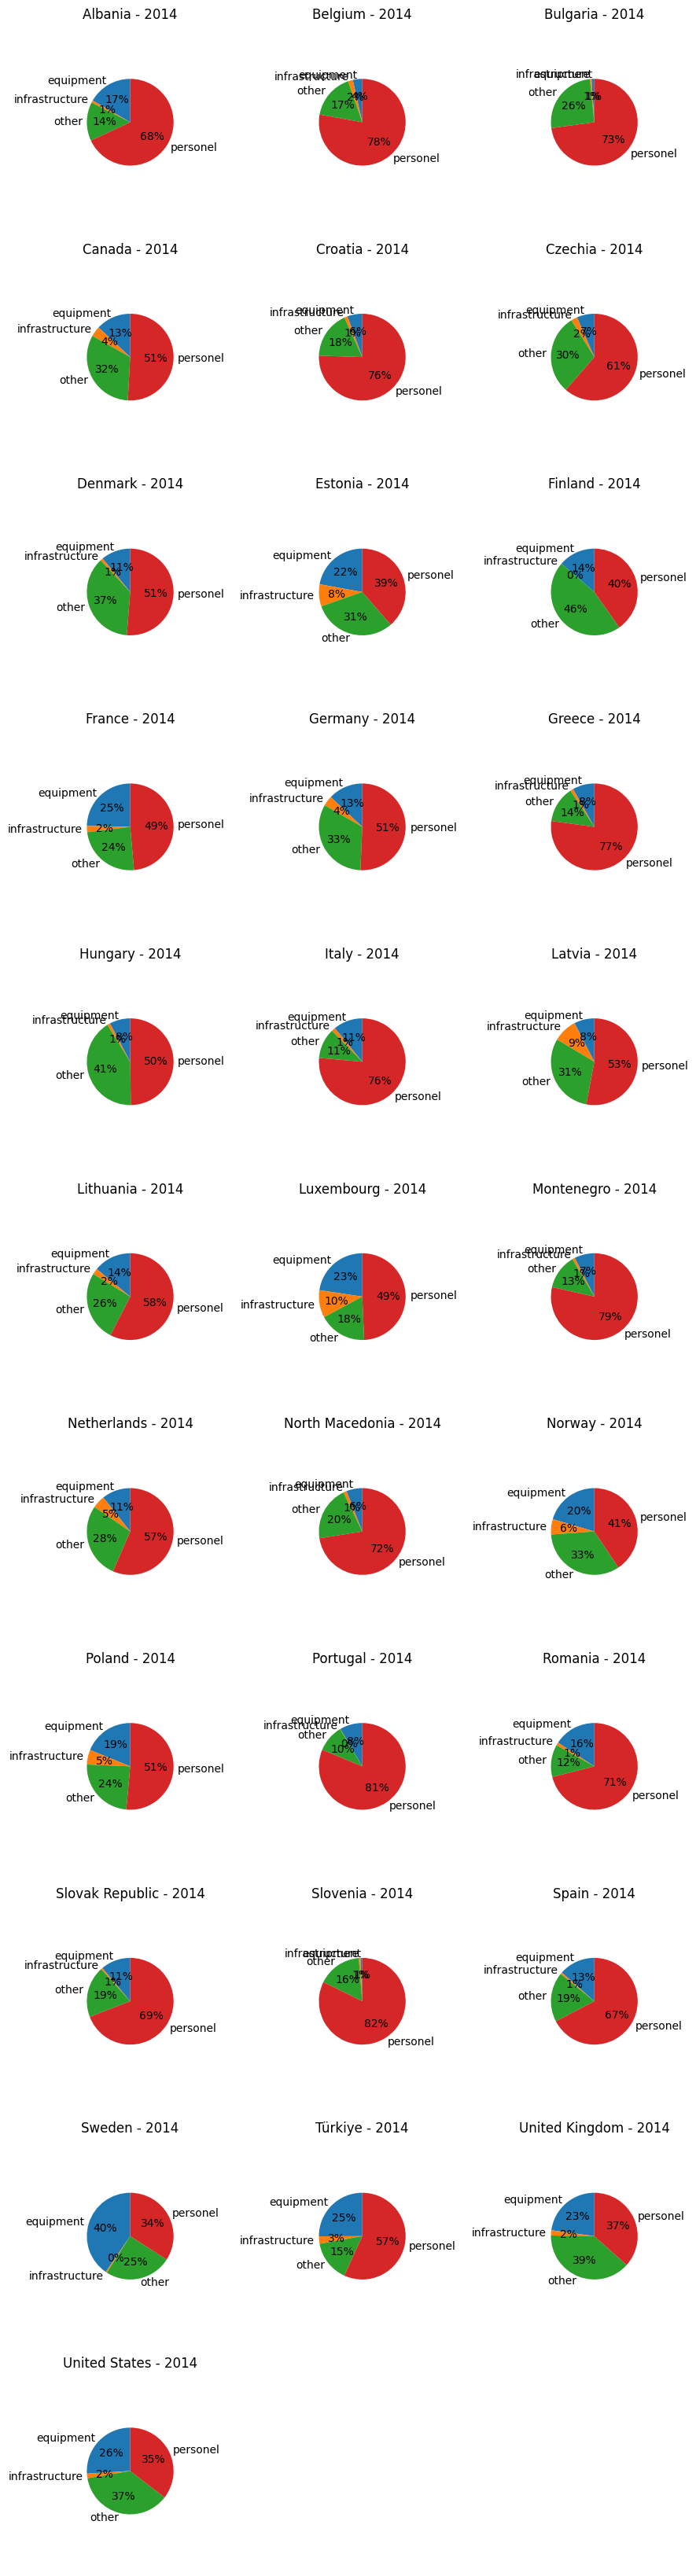

In [6]:
selected_year_expenditures = (expenditures[expenditures[YEAR] == selected_year]
                              .copy()
                              .pivot(index=COUNTRY, columns=CATEGORY, values=PERCENTAGE)
                              )

# Determine subfigure sizes
n_subfigs = len(selected_year_expenditures)
subfig_n_rows = math.ceil(n_subfigs / subfig_n_cols)

fig, axes = plt.subplots(subfig_n_rows, subfig_n_cols, figsize=(subfig_n_cols * 3, subfig_n_rows * 3))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for index, (country, row) in enumerate(selected_year_expenditures.iterrows()):
    axis = axes[index]
    categories, percentages = row.index, row.values
    axis.pie(percentages, labels=categories, autopct='%1.0f%%', startangle=pie_start_angle)
    axis.set_title(f"{country} - {selected_year}")
    axis.margins(0)
    axis.axis('equal')

# Hide any unused subplots
for axis in axes[n_subfigs:]:
    axis.axis('off')

plt.tight_layout()
plt.show()